In [5]:
import pandas as pd
import numpy as np


In [6]:
df = pd.read_csv("1429_1.csv")  # Or whatever filename is present


<ipython-input-6-fabeb2a52329>:1: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("1429_1.csv")  # Or whatever filename is present


In [7]:
df.head()

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


In [8]:
df.columns

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen',
       'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.userCity',
       'reviews.userProvince', 'reviews.username'],
      dtype='object')

In [9]:
df = df.loc[:, ['id','name','brand','categories']]


In [10]:
df.head()

,id,name,brand,categories
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta..."
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta..."
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta..."
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta..."
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta..."


In [11]:
df.isna().all()

,0
id,False
name,False
brand,False
categories,False


In [12]:
df.describe()

,id,name,brand,categories
count,34660,27900,34660,34660
unique,42,48,6,41
top,AVphgVaX1cnluZ0-DR74,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",Amazon,"Fire Tablets,Tablets,Computers & Tablets,All T..."
freq,10966,10966,28701,10966


In [13]:
df.shape

(34660, 4)

In [14]:
df.columns.duplicated()

array([False, False, False, False])

In [15]:
# Assuming you have a DataFrame named df
def extract_most_specific_category(cat_string):
    if pd.isna(cat_string):
        return "Unknown"
    categories = [c.strip() for c in cat_string.split(',') if c.strip()]
    return categories[-1] if categories else "Unknown"

# Apply function
df['specific_category'] = df['categories'].apply(extract_most_specific_category)


In [16]:
df.specific_category.value_counts()

,count
specific_category,
Frys,10977
Holiday Shop,6619
Fire TV,5056
Tablets & eReaders,3176
All Tablets,2902
Computers & Tablets,2814
Tablets & eBook Readers,642
Bluetooth Speakers,636
Wi-Fi 3G (Unlocked...,580


In [17]:
from random import sample
# create balanced datase
eBook_ctg = df[df['specific_category'] == 'Tablets & eReaders'].sample(n=2800, random_state=42)
holiday_ctg = df[df['specific_category'] == 'Holiday Shop'].sample(n=2800, random_state=42)
tv_ctg = df[df['specific_category'] == 'Fire TV'].sample(n=2800, random_state=42)
frys_ctg = df[df['specific_category'] == 'Frys'].sample(n=2800, random_state=42)
comptab_ctg = df[df['specific_category'] == 'Computers & Tablets'].sample(n=2800, random_state=42)

sampled_df = pd.concat([eBook_ctg, holiday_ctg, tv_ctg, frys_ctg, comptab_ctg])


In [18]:
sampled_df.specific_category.value_counts() # checking label distribution

,count
specific_category,
Tablets & eReaders,2800
Holiday Shop,2800
Fire TV,2800
Frys,2800
Computers & Tablets,2800


In [23]:
sampled_df.isnull().values.any()

np.True_

In [28]:
sampled_df.dropna(inplace=True)
sampled_df.drop('categories',axis=1)

,id,name,brand,specific_category
19732,AV1YnRtnglJLPUi8IJmV,Amazon Kindle Paperwhite - eBook reader - 4 GB...,Amazon,Tablets & eReaders
17904,AV1YnRtnglJLPUi8IJmV,Amazon Kindle Paperwhite - eBook reader - 4 GB...,Amazon,Tablets & eReaders
20348,AV1YnRtnglJLPUi8IJmV,Amazon Kindle Paperwhite - eBook reader - 4 GB...,Amazon,Tablets & eReaders
19117,AV1YnRtnglJLPUi8IJmV,Amazon Kindle Paperwhite - eBook reader - 4 GB...,Amazon,Tablets & eReaders
18463,AV1YnRtnglJLPUi8IJmV,Amazon Kindle Paperwhite - eBook reader - 4 GB...,Amazon,Tablets & eReaders
...,...,...,...,...
955,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,Computers & Tablets
1215,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,Computers & Tablets
2433,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,Computers & Tablets
1515,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,Computers & Tablets


In [29]:
sampled_df.isnull().sum()

,0
id,0
name,0
brand,0
categories,0
specific_category,0


In [30]:
sampled_df.size

54580

In [32]:
sampled_df['text_for_clustering'] = (
    df['brand'].fillna('') + ' ' +
    df['specific_category'].fillna('') + ' ' +
    df['name'].fillna('')
)
category_texts = sampled_df['text_for_clustering'].tolist()


In [33]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
category_embeddings = model.encode(category_texts, show_progress_bar=True)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/342 [00:00<?, ?it/s]

In [34]:
from sklearn.cluster import KMeans

k = 5  # adjust as needed
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(category_embeddings)
sampled_df['cluster'] = clusters

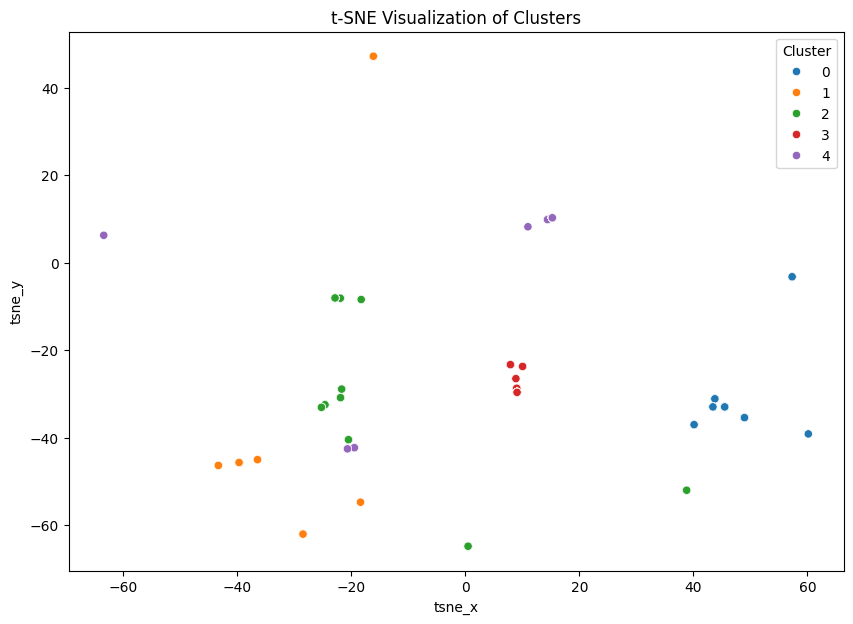

In [35]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Reduce embeddings to 2D
tsne = TSNE(n_components=2, random_state=42)
tsne_embeddings = tsne.fit_transform(category_embeddings)

# Add to DataFrame
sampled_df['tsne_x'] = tsne_embeddings[:, 0]
sampled_df['tsne_y'] = tsne_embeddings[:, 1]

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(data=sampled_df, x='tsne_x', y='tsne_y', hue='cluster', palette='tab10')
plt.title("t-SNE Visualization of Clusters")
plt.legend(title="Cluster")
plt.show()


In [36]:
from sklearn.model_selection import train_test_split

# If you're training a model to predict the cluster (for example)
X = sampled_df['text_for_clustering']  # or another feature column
y = sampled_df['cluster']       # or df['cluster'] if you're not labeling

# Split into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify keeps class balance
)


In [37]:
from sentence_transformers import SentenceTransformer

model_v2 = SentenceTransformer('all-MiniLM-L6-v2')

# Encode combined text
X_train_emb = model.encode(X_train.tolist(), show_progress_bar=True)
X_test_emb = model.encode(X_test.tolist(), show_progress_bar=True)

Batches:   0%|          | 0/273 [00:00<?, ?it/s]

Batches:   0%|          | 0/69 [00:00<?, ?it/s]

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_emb, y_train)

# Predict on test set
y_pred = clf.predict(X_test_emb)

# Evaluate
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       209
           1       1.00      1.00      1.00       570
           2       1.00      1.00      1.00       597
           3       1.00      1.00      1.00       250
           4       1.00      1.00      1.00       558

    accuracy                           1.00      2184
   macro avg       1.00      1.00      1.00      2184
weighted avg       1.00      1.00      1.00      2184



In [43]:
sampled_df.specific_category.unique()

array(['Tablets & eReaders', 'Holiday Shop', 'Frys',
       'Computers & Tablets'], dtype=object)

In [44]:
sampled_df.cluster.unique()

array([2, 3, 0, 1, 4], dtype=int32)

In [56]:
def predict_category(text):
    emb = model.encode([text])
    pred = clf.predict(emb)
    cluster_names = {
     2: 'Tablets & eReaders',
     0: 'Holiday Shop',
     4: 'Fire TV',
     3: 'Frys',
     1: 'Computers & Tablets'
}
    result = cluster_names.get(pred[0], "Unknown category")  # Use get() to handle any out-of-bound values
    return result

# Try it:
#predict_category("Amazon Fire HD Tablet")
predict_category("Considered by the Irish Times as one of the most brilliant flights of pure fancy ever recorded, this amazing story explores the beauty and untamed nature of a faraway world, where wild creatures crowd the fantastic landscape and demented torturers dominate victims with their bizarre mental powers.")


'Tablets & eReaders'